In [1]:
import os

import pandas as pd
from pathlib import Path

os.chdir(r"/home/enzo-maldinni/Documentos/SIGAMA-data-analysis")
print(os.getcwd())

from src.utils.parsing import parse_args, load_config

import sys
sys.argv = [sys.argv[0]]

args = parse_args()
cfg = load_config(args)

paths = cfg["paths"]

clusters_path = f'{cfg["paths"]["processed"]}'

print(clusters_path)

users_file = Path(clusters_path) / "usuario_202603050949_limpo.csv"

print(users_file)


/home/enzo-maldinni/Documentos/SIGAMA-data-analysis
data/processed
data/processed/usuario_202603050949_limpo.csv


In [2]:
import pandas as pd
import re
import unicodedata

def normalize_text(text):
    if pd.isna(text):
        return text
    
    # remover acentos
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")
    
    # lowercase
    text = text.lower()
    
    # remover hífen no início
    text = re.sub(r"^-+", "", text)
    
    # remover pontuação
    text = re.sub(r"[^\w\s]", "", text)
    
    # remover espaços extras
    text = re.sub(r"\s+", " ", text)
    
    text = text.strip()
    
    # capitalizar
    text = text.capitalize()
    
    return text

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar CSV
df = pd.read_csv(users_file)

# Visualizar
df.head()

bool_cols = [
    "bo_emitentegta", "bo_emitentegtv", "email_verificado",
    "bo_veterinario", "bo_emitentegtvexterno",
    "bo_classificadorsemente", "bo_permissao_cancelamento_gta",
    "bo_primeiroacesso"
]

for col in bool_cols:
    df[col] = df[col].astype(bool)

for col in bool_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

df.groupby(["bo_emitentegta", "email_verificado"]).size()

df["tem_papel"] = df[[
    "bo_emitentegta",
    "bo_veterinario",
    "bo_classificadorsemente"
]].any(axis=1)

df["tem_papel"].value_counts()

df["nu_tentativas"].describe()

df[df["bo_primeiroacesso"] == False].shape[0]

df.groupby("bo_primeiroacesso")["nu_tentativas"].mean()

df[df["nu_tentativas"] > 3]

anomalias = df[
    (df["nu_tentativas"] > 3) &
    (df["bo_primeiroacesso"] == False)
]

anomalias

df[df["email_verificado"] == False]

df.groupby("email_verificado")["nu_tentativas"].mean()

#plt.hist(df["nu_tentativas"], bins=10)
#plt.title("Distribuição de Tentativas")
#plt.xlabel("Tentativas")
#plt.ylabel("Quantidade")
#plt.show()

#plt.boxplot(df["nu_tentativas"])
#plt.title("Outliers de Tentativas")
#plt.show()


bo_emitentegta
bo_emitentegta
False    342652
True       3073
Name: count, dtype: int64

bo_emitentegtv
bo_emitentegtv
False    345677
True         48
Name: count, dtype: int64

email_verificado
email_verificado
False    321406
True      24319
Name: count, dtype: int64

bo_veterinario
bo_veterinario
False    345716
True          9
Name: count, dtype: int64

bo_emitentegtvexterno
bo_emitentegtvexterno
False    345712
True         13
Name: count, dtype: int64

bo_classificadorsemente
bo_classificadorsemente
False    345725
Name: count, dtype: int64

bo_permissao_cancelamento_gta
bo_permissao_cancelamento_gta
False    345725
Name: count, dtype: int64

bo_primeiroacesso
bo_primeiroacesso
False    295352
True      50373
Name: count, dtype: int64


/tmp/ipykernel_11499/1787880653.py:5: DtypeWarning: Columns (0: bo_emitentegta, 1: bo_primeiroacesso) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(users_file)


email_verificado
False    1.000000
True     1.001933
Name: nu_tentativas, dtype: float64

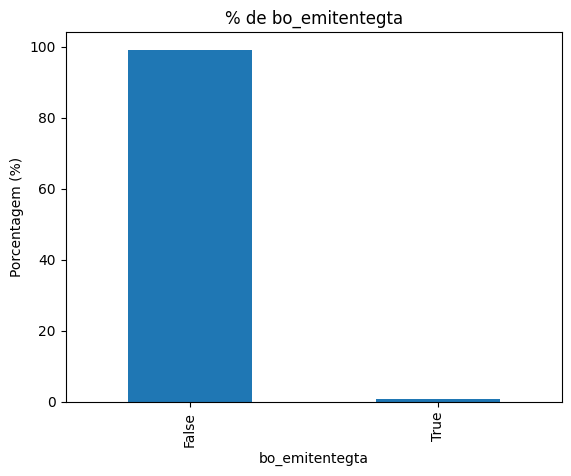

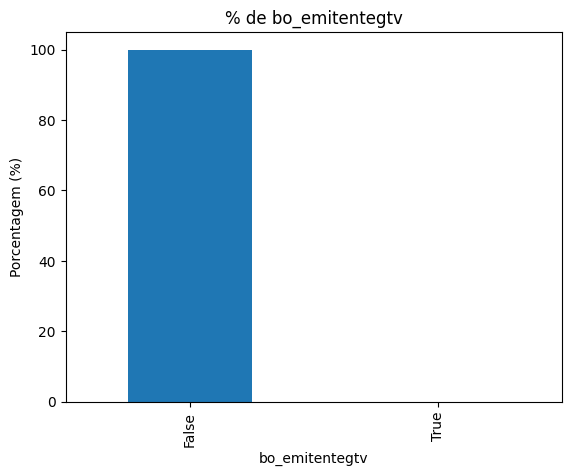

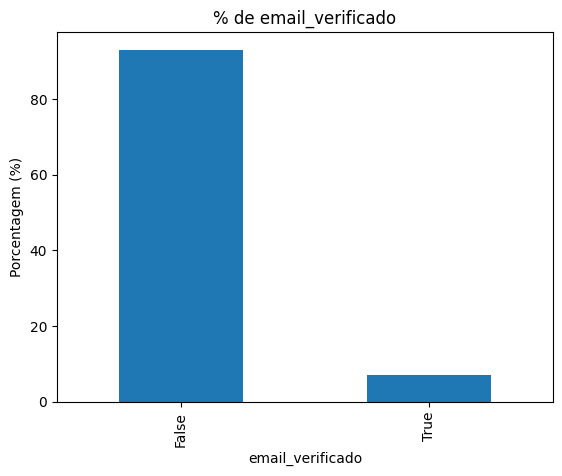

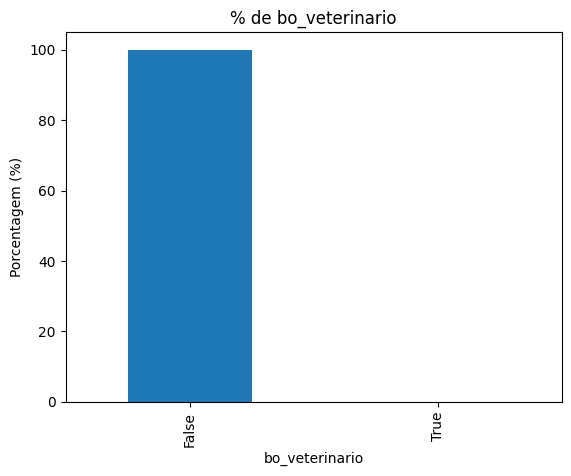

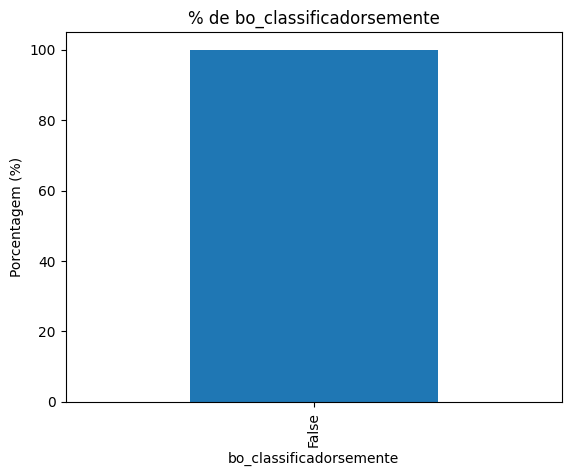

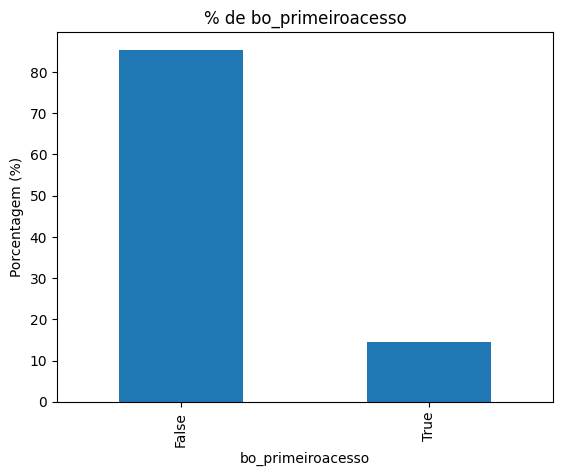

In [7]:
cols = [
    "bo_emitentegta", "bo_emitentegtv", "email_verificado",
    "bo_veterinario", "bo_classificadorsemente",
    "bo_primeiroacesso"
]

for col in cols:
    (df[col].value_counts(normalize=True) * 100).plot(kind="bar")
    plt.title(f"% de {col}")
    plt.ylabel("Porcentagem (%)")
    plt.show()

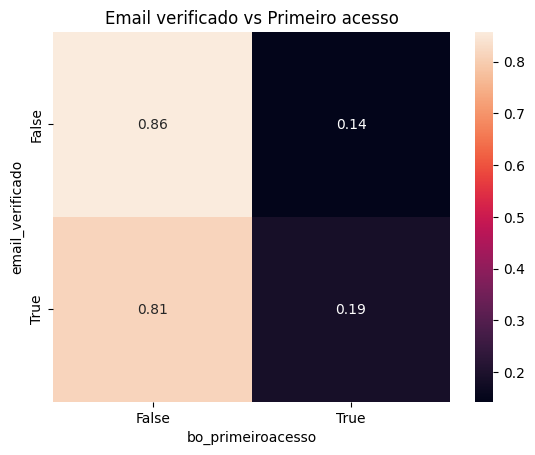

In [10]:
import seaborn as sns

cross = pd.crosstab(df["email_verificado"], df["bo_primeiroacesso"], normalize="index")

sns.heatmap(cross, annot=True, fmt=".2f")
plt.title("Email verificado vs Primeiro acesso")
plt.show()

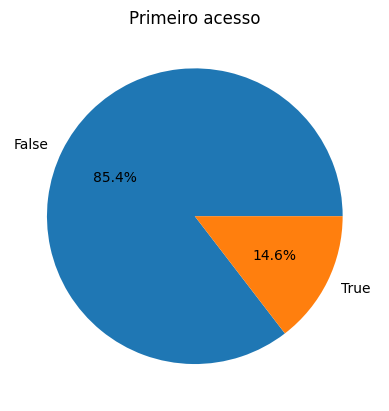

In [14]:
(df["bo_primeiroacesso"].value_counts(normalize=True) * 100).plot(kind="pie", autopct="%1.1f%%")
plt.title("Primeiro acesso")
plt.ylabel("")
plt.show()

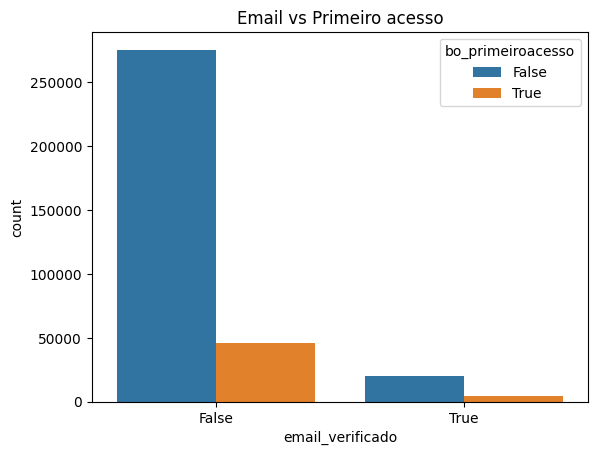

In [15]:
sns.countplot(x="email_verificado", hue="bo_primeiroacesso", data=df)
plt.title("Email vs Primeiro acesso")
plt.show()